<a href="https://colab.research.google.com/github/isil-slck/Predict-Greenweez-Churners-/blob/main/ISIL_of_Predict_Greenweez_Churners_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predict Greenweez Churners


In this project, it is analyzed Greenweez's client database to predict which customers are likely to make a second purchase within 3 months of their first order.



## Data exploration


a) Dataset Overview

Historical sales data is available from 2019 to 2021.

The goal is to build a model that helps identify potential repeat customers to support retention strategies.

Let’s dive into the data and uncover insights! 👇

In [1]:
from google.colab import auth
import pandas as pd

# Will collect your credentials
auth.authenticate_user()

# Query Bigquery
query = "SELECT * FROM `data-analytics-bootcamp-363212.course33.gwz_churn`"
project = "data-analytics-bootcamp-363212"

df = pd.read_gbq(query=query, project_id=project)

<ipython-input-1-794817e1e9d0>:11: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(query=query, project_id=project)


b) Let's take a look at the data.

1. Let's check first rows.
2. What's the shape of our data?
3. Are there any null values?  
4. What is our target?

In [3]:
df.head()

,date_date,orders_id,customers_id,nb_past_orders,avg_basket,total_purchase_cost,avg_quantity,total_quantity,nb_days_since_last_order,avg_nb_unique_products,total_nb_codes,re_purchase
0,2021-03-08,797405,207754,3,65.456667,196.37,29.333333,88,0,23.000000,1,0
1,2021-06-23,914331,229390,2,84.650000,169.30,40.000000,80,0,34.500000,1,0
2,2021-04-27,857750,4921,3,48.343333,145.03,20.000000,60,0,11.666667,1,1
3,2021-02-28,786589,10797,8,74.970000,599.76,26.500000,212,0,20.750000,8,1
4,2021-06-08,901782,116681,3,62.113333,186.34,16.666667,50,0,9.333333,1,0


In [2]:
df['customers_id'].nunique()

172523

In [4]:
df.shape

(381398, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381398 entries, 0 to 381397
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   date_date                 381398 non-null  dbdate 
 1   orders_id                 381398 non-null  Int64  
 2   customers_id              381398 non-null  Int64  
 3   nb_past_orders            381398 non-null  Int64  
 4   avg_basket                381398 non-null  float64
 5   total_purchase_cost       381398 non-null  float64
 6   avg_quantity              381398 non-null  float64
 7   total_quantity            381398 non-null  Int64  
 8   nb_days_since_last_order  381398 non-null  Int64  
 9   avg_nb_unique_products    381398 non-null  float64
 10  total_nb_codes            381398 non-null  Int64  
 11  re_purchase               381398 non-null  Int64  
dtypes: Int64(7), dbdate(1), float64(4)
memory usage: 37.5 MB


In [6]:
df.isnull().sum()

,0
date_date,0
orders_id,0
customers_id,0
nb_past_orders,0
avg_basket,0
total_purchase_cost,0
avg_quantity,0
total_quantity,0
nb_days_since_last_order,0
avg_nb_unique_products,0


Target = re_purchase

c) Is the column `orders_id` useful for our analysis?

Orders_id is not useful in this case! It is the unique identifier for the Greenweez database, but doesn't provide any info that it can be used to predict reconversions.


d) Now, delete `orders_id` and `date_date` columns.

In [8]:
df_new = df.drop(columns = ['orders_id','date_date'])

e) Have a look at whether the columns values are on different scales. To do this, use the DataFrame `.describe()` method to compare them.



In [9]:
df_new.describe()

,customers_id,nb_past_orders,avg_basket,total_purchase_cost,avg_quantity,total_quantity,nb_days_since_last_order,avg_nb_unique_products,total_nb_codes,re_purchase
count,381398.0,381398.0,381398.000000,381398.000000,381398.000000,381398.0,381398.0,381398.000000,381398.0,381398.0
mean,161066.560242,2.058692,51.570302,124.525402,13.558555,33.825301,0.0,8.392141,0.544751,0.476864
std,95853.282456,2.030991,41.144718,291.427518,13.202761,71.181359,0.0,7.364444,1.441715,0.499465
min,2.0,1.0,0.000000,0.000000,1.000000,1.0,0.0,1.000000,0.0,0.0
25%,69762.0,1.0,26.290000,30.310000,5.500000,7.0,0.0,3.000000,0.0,0.0
50%,174880.0,1.0,43.760000,65.550000,10.333333,16.0,0.0,6.500000,0.0,0.0
75%,244394.0,2.0,66.840000,150.350000,18.000000,38.0,0.0,11.500000,1.0,1.0
max,314334.0,61.0,4726.440000,22738.110000,1480.000000,3557.0,0.0,163.000000,57.0,1.0


The features are indeed on different scales. For example, total_nb_codes in comparison with avg_basket.

As a result, it needs to use a normalization technique.


f) Set column `customers_id` as index to keep customer_id information.

In [10]:
df_new.set_index('customers_id')

,nb_past_orders,avg_basket,total_purchase_cost,avg_quantity,total_quantity,nb_days_since_last_order,avg_nb_unique_products,total_nb_codes,re_purchase
customers_id,,,,,,,,,
207754,3,65.456667,196.37,29.333333,88,0,23.000000,1,0
229390,2,84.650000,169.30,40.000000,80,0,34.500000,1,0
4921,3,48.343333,145.03,20.000000,60,0,11.666667,1,1
10797,8,74.970000,599.76,26.500000,212,0,20.750000,8,1
116681,3,62.113333,186.34,16.666667,50,0,9.333333,1,0
...,...,...,...,...,...,...,...,...,...
205285,2,81.125000,162.25,22.500000,45,0,20.000000,1,0
19543,2,59.750000,119.50,22.500000,45,0,20.000000,0,0
165488,2,73.585000,147.17,22.500000,45,0,20.000000,0,0


Note that for this exercise, the data has already been partially cleaned and prepared** 🔧.


## Modeling

a) Split dataset into a train and a test set (this should give you an `X_train`, `X_test`, `y_train` and `y_test`).

test_size of 20%.

In [11]:
from sklearn.model_selection import train_test_split

# every columns in X variable except re_purchase which is our target
X = df_new.iloc[:,:-1]
y = df_new.iloc[:,-1]

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=30)
# store customers_ids for after
test_customers_ids = X_test.index

In [12]:
X_test.head()

,customers_id,nb_past_orders,avg_basket,total_purchase_cost,avg_quantity,total_quantity,nb_days_since_last_order,avg_nb_unique_products,total_nb_codes
367021,108744,3,54.086667,162.26,27.000000,81,0,16.000000,0
332333,50473,1,36.090000,36.09,13.000000,13,0,11.000000,0
24350,213163,3,77.983333,233.95,18.666667,56,0,16.333333,0
221998,106344,1,26.810000,26.81,5.000000,5,0,5.000000,0
266525,282237,1,17.970000,17.97,7.000000,7,0,7.000000,0


In [13]:
X_train.head()

,customers_id,nb_past_orders,avg_basket,total_purchase_cost,avg_quantity,total_quantity,nb_days_since_last_order,avg_nb_unique_products,total_nb_codes
201602,158879,1,29.570000,29.57,5.0,5,0,4.000000,0
17217,18930,26,104.503462,2717.09,19.0,494,0,7.538462,0
286431,225690,1,29.980000,29.98,8.0,8,0,8.000000,0
104544,95688,1,14.190000,14.19,1.0,1,0,1.000000,0
201501,148292,1,24.780000,24.78,5.0,5,0,4.000000,0


b) to apply normalization on the data. It is used a StandardScaler for this transformation.


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# apply same transformation on X_test
X_test = scaler.transform(X_test)

c) Let's check the types of X_train and X_test?

In [15]:
print(type(X_test),type(X_train))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


d) Before building the model. let's create a baseline to compare the futur models!

For this example, calculate the accuracy score for a stupid model returning always 1.

In [16]:
y_test.shape

(76280,)

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score

baseline_y_pred = pd.Series(np.ones([76280]))

baseline_accuracy = accuracy_score(y_test, baseline_y_pred)

print(f"Baseline accuracy is {round(baseline_accuracy,2)}")

Baseline accuracy is 0.48


Now that we have a baseline, even if it's poor, we will try to surpass it!

e) It is used a logistic regression model.

In [18]:
from sklearn.linear_model import LogisticRegression

# train model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# store predictions
y_pred = clf.predict(X_test)

In [19]:
y_pred

array([1., 0., 1., ..., 0., 0., 1.])

f) Calculate the accuracy for test data.


In [20]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7299816465652857

Logistic regression score corresponds to accuracy.
We see here 73% accuracy on both train and test data. It means that 73% of our predictions are good.

There is no overfitting as there is no difference in scores between train and test


g) Accuracy is one way to judge model performance, but plotting a confusion matrix on the test data can be more informative.

plot confusion matrix.

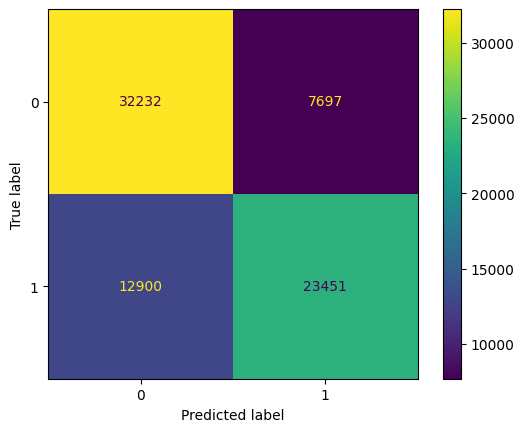

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

confusion_matrix = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

h) From your confusion matrix and the below picture, calculate:
- precision
- recall
- accuracy

Remember to make sure you are using the values associated with the correct labels when doing so!

![confusion matrix](https://wagon-public-assets.s3.eu-west-3.amazonaws.com/pchl73lhb84nyh6ic4yzw98bl2me)

In [ ]:
#accuracy = (TP+TN)/ all value
#precision = TP / (TP + FP) in predict positive or 1 value condition,calculate true postive predicted ratio
#recall = TP/(TP + FN) in real postive or 1 value condition , calculate true positive predicted ratio

accuracy = (23451+32231) / (32231 + 23451 +12900 + 7697)
precision = 23451 / (7697 + 23451)
recall = 23451 / (23451 + 12900)
print(f' acc : {accuracy:.2f}, pre :{precision:.2f}, recall :{recall:.2f}')

 acc : 0.73, pre :0.75, recall :0.65


i) What is the percent of churners the model correctly detected? Is it good?

In [ ]:
#number of churners prediction correctly = FP / FP+FN
ratio = 32232 / (32232 +7697)
ratio

0.8072328382879611


Not bad at all, we have now a model to identify 81.82% of churners :)


j) Let's get probability to repurchase or not (column not churner).

In [22]:
y_pro = clf.predict_proba(X_test)
y_pro

array([[0.21591773, 0.78408227],
       [0.66610101, 0.33389899],
       [0.22443801, 0.77556199],
       ...,
       [0.54956733, 0.45043267],
       [0.8237365 , 0.1762635 ],
       [0.24664831, 0.75335169]])

In [23]:
proba = pd.DataFrame(clf.predict_proba(X_test), columns=["Churner", "Not churner"], index=test_customers_ids)
proba

,Churner,Not churner
367021,0.215918,0.784082
332333,0.666101,0.333899
24350,0.224438,0.775562
221998,0.736068,0.263932
266525,0.797161,0.202839
...,...,...
350294,0.097356,0.902644
176047,0.813837,0.186163
323633,0.549567,0.450433
93297,0.823736,0.176264


k) Filter this dataframe on customers who have between 20% and 50% probability to re purchase.

Customers with a probability of less than 20% to repurchase are considered lost.

In [24]:
#re-purchase customer prediction
re_pruchase_cust = proba[(proba['Not churner'] >= 0.20) & (proba['Not churner'] <= 0.50)]
re_pruchase_cust

,Churner,Not churner
332333,0.666101,0.333899
221998,0.736068,0.263932
266525,0.797161,0.202839
294002,0.701246,0.298754
251393,0.754921,0.245079
...,...,...
324417,0.510229,0.489771
78523,0.521093,0.478907
223030,0.703948,0.296052
187988,0.537652,0.462348


In [25]:
#lost customer
lost_cust = proba[proba['Not churner'] <= 0.20]
lost_cust

,Churner,Not churner
229382,0.810052,0.189948
105521,0.811632,0.188368
106266,0.831485,0.168515
142610,0.828499,0.171501
94508,0.832557,0.167443
...,...,...
143179,0.809464,0.190536
117969,0.807018,0.192982
102654,0.803709,0.196291
176047,0.813837,0.186163


l) The model predicts churners.

Using this model, suggest a process that can be implemented at GreenWeez to help the company reduce the churn rate.



On a regular basis, predict possible churners and send this info back to the CRM via ELT.

The CRM team will then target those users who are predicted as likely to churn by sending them coupon codes, discounts, ...
things that will hopefully retain them!
